# DATA 5322 – Practical Homework 1: Decision Trees
**Author:** Paul Skentzos  
**Course:** Statistical Machine Learning II  
**Data:** National Survey on Drug Use and Health (NSDUH), pre-processed youth subset

---
## Task
**Inverstigate factors that are correlated with youth drug use.**

## Research Question

> **Which youth social, family, and school experiences predict substance use outcomes?**

We investigate three formulations of this question. One per required problem type:

| # | Problem Type | Target | Description |
|---|---|---|---|
| 1 | Binary Classification | `ALCFLAG` | Has a youth *ever* used alcohol? |
| 2 | Multi-class Classification | `MRJYDAYS` (3-class) | Is marijuana use *never / occasional / frequent*? |
| 3 | Regression | `IRALCFY` | How many days per year does a youth use alcohol? |

**Models demonstrated** (each at least once, across the three problems):  
Single Decision Tree · Bagging · Random Forest · AdaBoost · Gradient Boosting

---


## Setup

In this section, we'll add all the necessary libraries that will be used for this work.

In [1]:
# ── Libraries ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier,
                              GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, RocCurveDisplay,
                              mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance

SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Libraries loaded ✓")


Libraries loaded ✓


## Load & Inspect Data

Here we will load and inspect the data that we will be using. In this case, the data is the
"cleaned" `youth_data.csv`.

It is assumed that `youth_data` will be located in the directory that this jupyter notebook is run


In [2]:
df_raw = pd.read_csv("youth_data.csv")
print(f"Shape: {df_raw.shape}")
print(f"\nColumn list:")
for i, c in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {c}")


Shape: (10561, 79)

Column list:
   1. IRALCFY
   2. IRMJFY
   3. IRCIGFM
   4. IRSMKLSS30N
   5. IRALCFM
   6. IRMJFM
   7. IRCIGAGE
   8. IRSMKLSSTRY
   9. IRALCAGE
  10. IRMJAGE
  11. MRJFLAG
  12. ALCFLAG
  13. TOBFLAG
  14. ALCYDAYS
  15. MRJYDAYS
  16. ALCMDAYS
  17. MRJMDAYS
  18. CIGMDAYS
  19. SMKLSMDAYS
  20. SCHFELT
  21. TCHGJOB
  22. AVGGRADE
  23. STNDSCIG
  24. STNDSMJ
  25. STNDALC
  26. STNDDNK
  27. PARCHKHW
  28. PARHLPHW
  29. PRCHORE2
  30. PRLMTTV2
  31. PARLMTSN
  32. PRGDJOB2
  33. PRPROUD2
  34. ARGUPAR
  35. YOFIGHT2
  36. YOGRPFT2
  37. YOHGUN2
  38. YOSELL2
  39. YOSTOLE2
  40. YOATTAK2
  41. PRPKCIG2
  42. PRMJEVR2
  43. PRMJMO
  44. PRALDLY2
  45. YFLPKCG2
  46. YFLTMRJ2
  47. YFLMJMO
  48. YFLADLY2
  49. FRDPCIG2
  50. FRDMEVR2
  51. FRDMJMON
  52. FRDADLY2
  53. TALKPROB
  54. PRTALK3
  55. PRBSOLV2
  56. PREVIOL2
  57. PRVDRGO2
  58. GRPCNSL2
  59. PREGPGM2
  60. YTHACT2
  61. DRPRVME3
  62. ANYEDUC3
  63. RLGATTD
  64. RLGIMPT
  65. RLGDCSN
  66. RLGFR

In [3]:
# Quick look at our three target variables
# The three variables that we are tracking for this experiment are:
# ALCFLAG - has alcohol ever been used?
# MRJYDAYS - number of days of MJ use in the past year
# IRALCFY - how often has alcohol been used in the past year

targets = {
    'ALCFLAG  (binary)':   df_raw['ALCFLAG'].value_counts().sort_index(),
    'MRJYDAYS (multi)':    df_raw['MRJYDAYS'].value_counts().sort_index(),
    'IRALCFY  (regression)': df_raw['IRALCFY'].value_counts().sort_index().iloc[:10],
}
for name, vc in targets.items():
    print(f"\n{name}:")
    print(vc.to_string())



ALCFLAG  (binary):
ALCFLAG
0    8157
1    2404

MRJYDAYS (multi):
MRJYDAYS
1     460
2     309
3     135
4     306
5     125
6    9226

IRALCFY  (regression):
IRALCFY
1     326
2     221
3     190
4      87
5     121
6      54
7      27
8      38
9      12
10     40


## Feature Selection & Leakage Audit

We use 47 youth-experience items (school, parenting, peers, risk behaviors, religion)
and 8 demographic variables as predictors across all three problems.

Leakage prevention: All substance-use outcome variables
(`MRJFLAG`, `TOBFLAG`, all frequency/age-of-first-use columns) are excluded from
predictors. We also exclude the other two targets when modeling each problem.
For example, `MRJYDAYS` and `IRALCFY` are never used as features when predicting `ALCFLAG`.


In [4]:
# ── Youth experience columns (binary 1=yes / 2=no) ────────────────────────────
youth_exp_cols = [
    # School feelings
    'SCHFELT',   # youth felt school important. Subjective
    'TCHGJOB',   # teachers do a good job. I am not sure how this is actually measured.
    'AVGGRADE',  # grades mostly A or B
    # School drug norms
    'STNDSCIG',  # students use of cigarettes
    'STNDSMJ',   # students use of marijuana
    'STNDALC',   # students use of alcohol
    'STNDDNK',   # students who participated in heavy drinking
    # Parental involvement
    'PARCHKHW',  # parents check homework
    'PARHLPHW',  # parents help with homework
    'PRCHORE2',  # parents assign chores
    'PRLMTTV2',  # parents limit TV
    'PARLMTSN',  # parents limit time with friends during school night
    'PRGDJOB2',  # parents praise for doing good job
    'PRPROUD2',  # parents express pride
    'ARGUPAR',   # argued with parents
    # Youth risk/delinquency
    'YOFIGHT2',  # gotten in a serious fight (serious/not serious?)
    'YOGRPFT2',  # fought in a group / with a group of students
    'YOHGUN2',   # carried a handgun
    'YOSELL2',   # sold drugs
    'YOSTOLE2',  # stolen / tried to steal
    'YOATTAK2',  # attacked with intent to harm
    # Parent drug behavior (youth perception)
    'PRPKCIG2',  # parents smoke cigarettes
    'PRMJEVR2',  # parents ever used marijuana
    'PRMJMO',    # parents used MJ past month
    'PRALDLY2',  # parents drink alcohol daily
    # Youth attitudes toward drugs
    'YFLPKCG2',  # OK for youth to smoke cigarettes (peers)
    'YFLTMRJ2',  # OK for youth to try marijuana (peers)
    'YFLMJMO',   # OK for youth to use MJ monthly (peers)
    'YFLADLY2',  # OK for youth to drink alcohol daily (peers)
    # Friends' drug use
    'FRDPCIG2',  # friends smoke cigarettes (close)
    'FRDMEVR2',  # friends ever tried marijuana (close)
    'FRDMJMON',  # friends use MJ monthly (close)
    'FRDADLY2',  # friends drink alcohol daily (close)
    # Protective / prevention factors
    'TALKPROB',  # talk to parent about problems
    'PRTALK3',   # parent talked about drug dangers
    'PRBSOLV2',  # parent taught problem solving
    'PREVIOL2',  # violence prevention program
    'PRVDRGO2',  # drug prevention program (outside school)
    'GRPCNSL2',  # group counseling at school
    'PREGPGM2',  # pregnancy prevention program
    'YTHACT2',   # involved in youth activities
    'DRPRVME3',  # received drug prevention message (outside of school)
    'ANYEDUC3',  # any drug education in school
    # Religion
    'RLGATTD',   # attends religious services (number of times)
    'RLGIMPT',   # religion important in life (subjective)
    'RLGDCSN',   # religion guides decisions
    'RLGFRND',   # friends share religious beliefs
]

# ── Demographic columns ────────────────────────────────────────────────────────
# EDUSCHGRD2 (11% skip codes) and EDUSKPCOM (27% skip codes) excluded
demo_cols = [
    'IRSEX',    # sex: 1=male, 2=female
    'NEWRACE2', # race: 7 categories
    'INCOME',   # family income: 1–4 (low→high)
    'POVERTY3', # poverty level: 1–3
    'IMOTHER',  # mother in household: 1=yes, 2=no, 3=don't know (age of mother not used)
    'IFATHER',  # father in household: 1=yes, 2=no, 3=don't know (age of father not used)
    'HEALTH2',  # overall health: 1–4 (poor→excellent)
    'COUTYP4',  # metro type: 1=large, 2=small, 3=nonmetro (no definitions other than this)
]

feature_cols = youth_exp_cols + demo_cols
print(f"Feature columns: {len(feature_cols)} ({len(youth_exp_cols)} youth exp + {len(demo_cols)} demographic)")


Feature columns: 55 (47 youth exp + 8 demographic)


## Data Cleaning

Three steps:
1. Mode imputation for NaN in youth-experience columns (all binary)
2. Recode binary 1/2 → 1/0 so that 1=yes, 0=no consistently
3. Target-specific cleaning for the regression target (`IRALCFY`)


In [5]:
# ── Work on a copy of the data ───────────────────────────────────────────
# Let's not mess with the original data set in case we come back to it
df = df_raw[feature_cols + ['ALCFLAG', 'MRJYDAYS', 'IRALCFY']].copy()

# ── Mode imputation for youth experience NaNs ────────────────────────────
nan_before = df[feature_cols].isnull().sum().sum()
for col in feature_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
nan_after = df[feature_cols].isnull().sum().sum()
print(f"NaN in features: {nan_before} → {nan_after} (mode imputed)")

# ── Recode binary 1/2 → 1/0 (1=yes, 0=no) ───────────────────────────────
# Applies to all youth-experience columns and household presence cols
binary_recode_cols = youth_exp_cols + ['IRSEX', 'IMOTHER', 'IFATHER']
for col in binary_recode_cols:
    if col in df.columns and df[col].max() == 2:
        df[col] = df[col].map({1: 1, 2: 0})

print(f"Binary recoding applied to {len(binary_recode_cols)} columns")
print(f"\nFinal data shape: {df.shape}")


NaN in features: 8017 → 0 (mode imputed)
Binary recoding applied to 50 columns

Final data shape: (10561, 58)


In [6]:
# ── Multi-class target: collapse MRJYDAYS -> 3 classes ────────────────────
# Original: 1=1-11 days, 2=12-49 days, 3=50-99 days, 4=100-299 days,
#           5=300+ days, 6=none in past year
# Collapsed: 0=Never (6), 1=Occasional (1-2), 2=Frequent (3-5)
mrj_map = {6: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
df['MRJ3CLASS'] = df['MRJYDAYS'].map(mrj_map)
print("MRJ3CLASS distribution:")
label_map = {0: 'Never', 1: 'Occasional', 2: 'Frequent'}
print(df['MRJ3CLASS'].map(label_map).value_counts().to_string())

# ── Regression target: IRALCFY ───────────────────────────────────────────
# 991 = never used alcohol -> recode to 0 days
# 993 = refused/don't know -> drop these rows
# There are other variables like this, but we will address this one only.
df_reg = df[df['IRALCFY'] != 993].copy()
df_reg['IRALCFY'] = df_reg['IRALCFY'].replace(991, 0)
print(f"\nRegression dataset: {len(df_reg)} rows after dropping 993 codes")
print(f"IRALCFY after cleaning: min={df_reg['IRALCFY'].min()}, "
      f"max={df_reg['IRALCFY'].max()}, mean={df_reg['IRALCFY'].mean():.1f}")


MRJ3CLASS distribution:
MRJ3CLASS
Never         9226
Occasional     769
Frequent       566

Regression dataset: 10022 rows after dropping 993 codes
IRALCFY after cleaning: min=0, max=339, mean=4.2


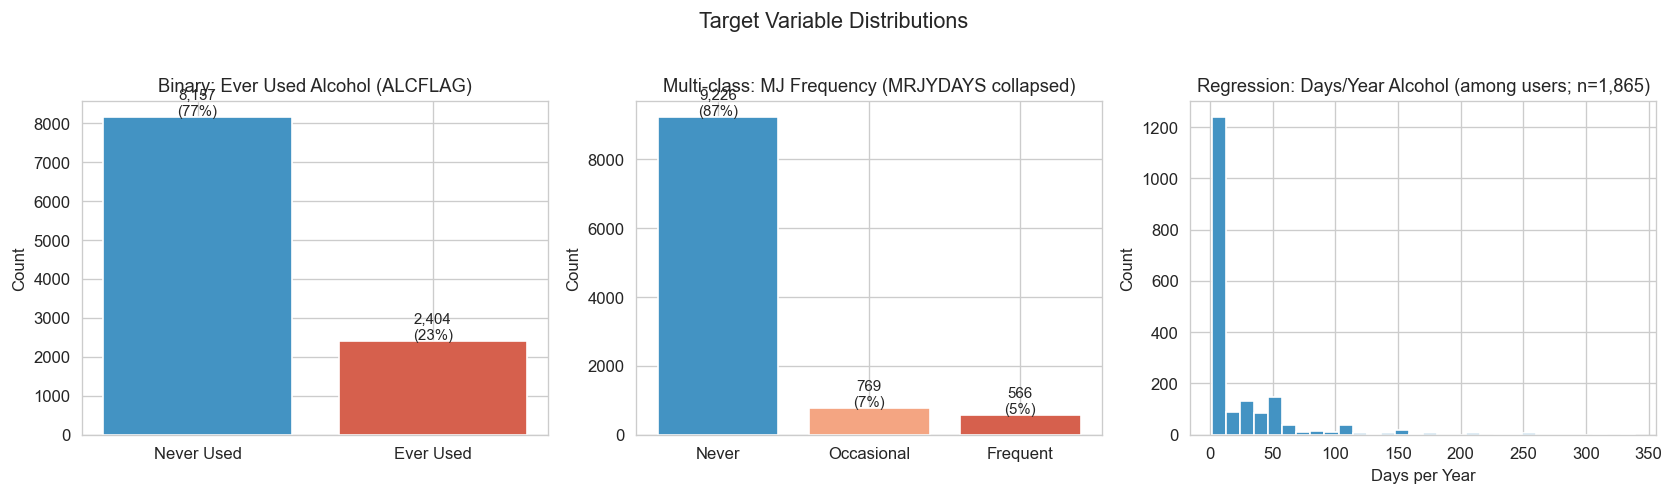

Saved: fig_eda_targets.png


In [7]:
# ── EDA summary figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Target 1 – ALCFLAG
vc1 = df['ALCFLAG'].value_counts().sort_index()
axes[0].bar(['Never Used', 'Ever Used'], vc1.values, color=['#4393c3', '#d6604d'])
axes[0].set_title('Binary: Ever Used Alcohol (ALCFLAG)', fontsize=11)
axes[0].set_ylabel('Count')
for i, v in enumerate(vc1.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.0%})', ha='center', fontsize=9)

# Target 2 – MRJ3CLASS
vc2 = df['MRJ3CLASS'].value_counts().sort_index()
axes[1].bar(['Never', 'Occasional', 'Frequent'], vc2.values,
            color=['#4393c3', '#f4a582', '#d6604d'])
axes[1].set_title('Multi-class: MJ Frequency (MRJYDAYS collapsed)', fontsize=11)
axes[1].set_ylabel('Count')
for i, v in enumerate(vc2.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df):.0%})', ha='center', fontsize=9)

# Target 3 – IRALCFY
alc_nonzero = df_reg[df_reg['IRALCFY'] > 0]['IRALCFY']
axes[2].hist(alc_nonzero, bins=30, color='#4393c3', edgecolor='white')
axes[2].set_title(f'Regression: Days/Year Alcohol (among users; n={len(alc_nonzero):,})', fontsize=11)
axes[2].set_xlabel('Days per Year')
axes[2].set_ylabel('Count')

plt.suptitle('Target Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_eda_targets.png', bbox_inches='tight')
plt.show()
print("Saved: fig_eda_targets.png")


---
## Problem 1: Binary Classification - Ever Used Alcohol (ALCFLAG)

Models Used: Single Decision Tree -> Random Forest -> AdaBoost
Evaluation Approach: Accuracy, ROC AUC, Classification Report, Confusion Matrix


In [8]:
# ── Train/test split (stratified) ────────────────────────────────────────────
X_bin = df[feature_cols]
y_bin = df['ALCFLAG']

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bin, y_bin, test_size=0.20, stratify=y_bin, random_state=SEED)
print(f"Train: {len(X_tr_b):,}  |  Test: {len(X_te_b):,}")
print(f"Positive rate  →  Train: {y_tr_b.mean():.1%}  |  Test: {y_te_b.mean():.1%}")


Train: 8,448  |  Test: 2,113
Positive rate  →  Train: 22.8%  |  Test: 22.8%


### Single Decision Tree (Binary)

Best max_depth (5-fold CV ROC AUC): 6  →  AUC = 0.796


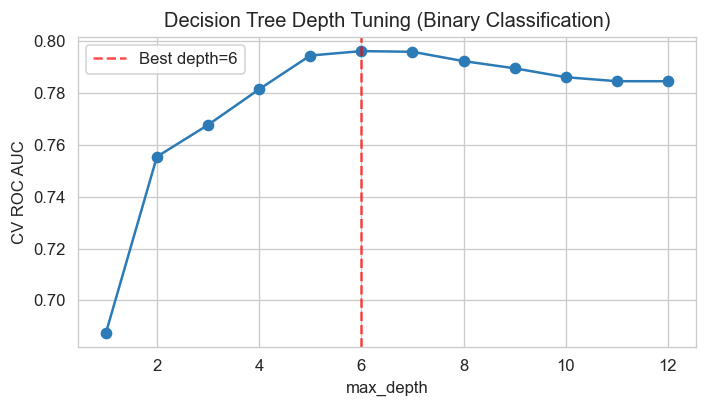

In [9]:
# ── Hyperparameter tuning: max_depth ─────────────────────────────────────────
depth_range = range(1, 13)
cv_auc = []
for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_b, y_tr_b, cv=5, scoring='roc_auc')
    cv_auc.append(scores.mean())

best_depth_b = depth_range[int(np.argmax(cv_auc))]
print(f"Best max_depth (5-fold CV ROC AUC): {best_depth_b}  →  AUC = {max(cv_auc):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range, cv_auc, 'o-', color='#2c7bb6')
ax.axvline(best_depth_b, color='red', linestyle='--', alpha=0.7, label=f'Best depth={best_depth_b}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV ROC AUC')
ax.set_title('Decision Tree Depth Tuning (Binary Classification)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_bin_dt_tuning.png', bbox_inches='tight')
plt.show()


In [10]:
# ── Fit best single DT ────────────────────────────────────────────────────────
dt_bin = DecisionTreeClassifier(
    max_depth=best_depth_b,
    criterion='gini',
    class_weight='balanced',
    min_samples_leaf=30,
    random_state=SEED
)
dt_bin.fit(X_tr_b, y_tr_b)

y_pred_dt_b  = dt_bin.predict(X_te_b)
y_proba_dt_b = dt_bin.predict_proba(X_te_b)[:, 1]

print("── Single DT ───────────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_dt_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_dt_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_dt_b,
      target_names=['Never Used', 'Ever Used']))


── Single DT ───────────────────────────────────
  Accuracy : 0.743
  ROC AUC  : 0.779

              precision    recall  f1-score   support

  Never Used       0.89      0.76      0.82      1632
   Ever Used       0.46      0.68      0.55       481

    accuracy                           0.74      2113
   macro avg       0.67      0.72      0.68      2113
weighted avg       0.79      0.74      0.76      2113



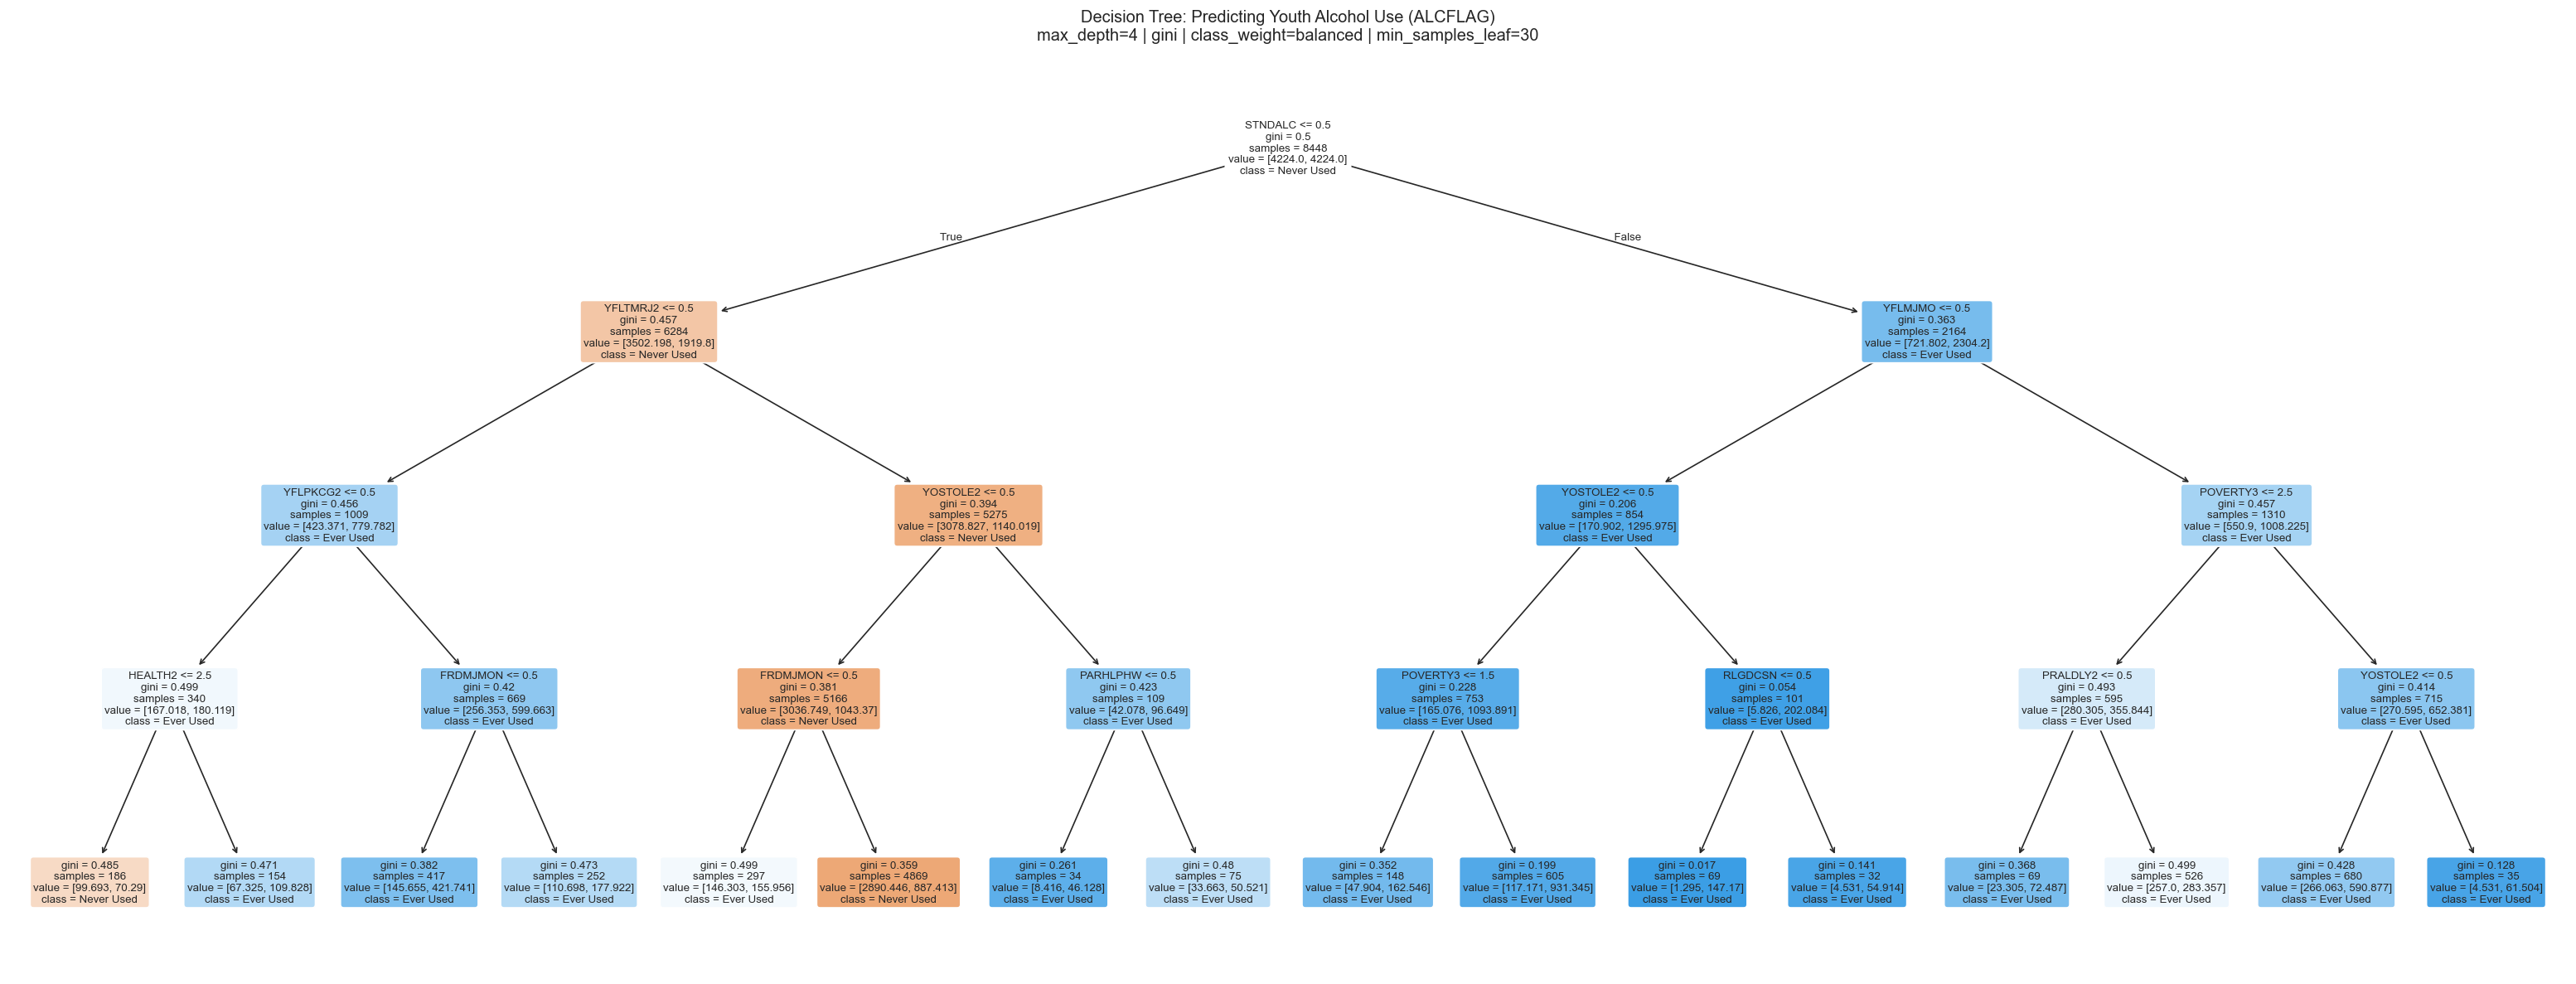


Text representation (depth=4 display tree):
|--- STNDALC <= 0.50
|   |--- YFLTMRJ2 <= 0.50
|   |   |--- YFLPKCG2 <= 0.50
|   |   |   |--- HEALTH2 <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- HEALTH2 >  2.50
|   |   |   |   |--- class: 1
|   |   |--- YFLPKCG2 >  0.50
|   |   |   |--- FRDMJMON <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- FRDMJMON >  0.50
|   |   |   |   |--- class: 1
|   |--- YFLTMRJ2 >  0.50
|   |   |--- YOSTOLE2 <= 0.50
|   |   |   |--- FRDMJMON <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- FRDMJMON >  0.50
|   |   |   |   |--- class: 0
|   |   |--- YOSTOLE2 >  0.50
|   |   |   |--- PARHLPHW <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- PARHLPHW >  0.50
|   |   |   |   |--- class: 1
|--- STNDALC >  0.50
|   |--- YFLMJMO <= 0.50
|   |   |--- YOSTOLE2 <= 0.50
|   |   |   |--- POVERTY3 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- POVERTY3 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- YOSTOLE2 >  0.50
|   |   |   |--- R

In [11]:
# ── Tree visualization (depth=4 for readability) ─────────────────────────────
# Python makes a mess of these trees if not managed properly.
dt_vis = DecisionTreeClassifier(
    max_depth=4, criterion='gini', class_weight='balanced',
    min_samples_leaf=30, random_state=SEED)
dt_vis.fit(X_tr_b, y_tr_b)

fig_tree, ax_tree = plt.subplots(figsize=(26, 10))
plot_tree(dt_vis, feature_names=feature_cols,
          class_names=['Never Used', 'Ever Used'],
          filled=True, rounded=True, fontsize=8, ax=ax_tree,
          impurity=True, proportion=False)
ax_tree.set_title(
    "Decision Tree: Predicting Youth Alcohol Use (ALCFLAG)\n"
    "max_depth=4 | gini | class_weight=balanced | min_samples_leaf=30",
    fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('fig_bin_dt_tree.png', bbox_inches='tight', dpi=140)
plt.show()
print("\nText representation (depth=4 display tree):")
print(export_text(dt_vis, feature_names=feature_cols))


### Random Forest (Binary)

In [12]:
# ── GridSearchCV tuning ───────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [4, 6],
    'max_features': ['sqrt'],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED),
    rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_gs.fit(X_tr_b, y_tr_b)
print(f"Best RF params: {rf_gs.best_params_}")
print(f"Best CV AUC   : {rf_gs.best_score_:.3f}")


Best RF params: {'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV AUC   : 0.817


── Random Forest ───────────────────────────────
  Accuracy : 0.752
  ROC AUC  : 0.795

              precision    recall  f1-score   support

  Never Used       0.89      0.78      0.83      1632
   Ever Used       0.47      0.66      0.55       481

    accuracy                           0.75      2113
   macro avg       0.68      0.72      0.69      2113
weighted avg       0.79      0.75      0.77      2113



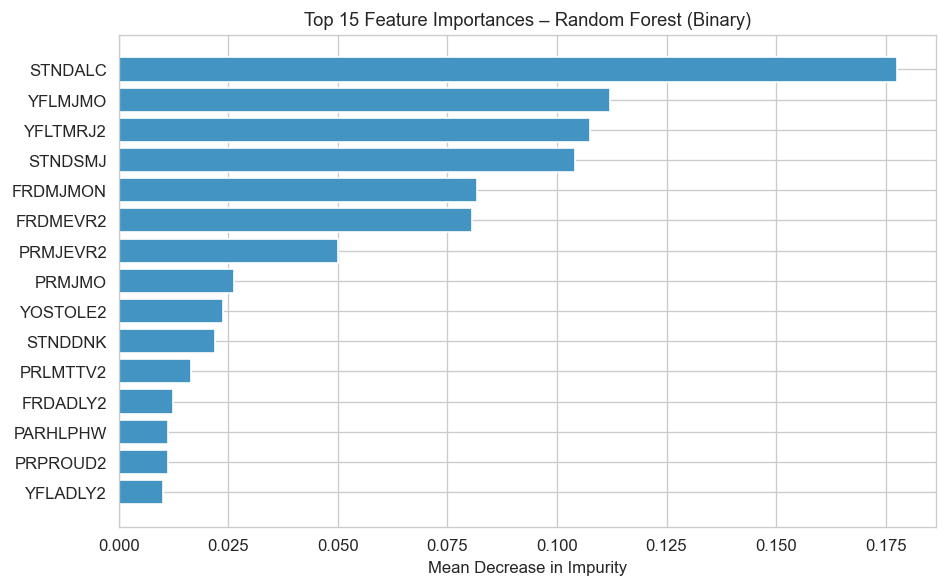

In [13]:
rf_bin = rf_gs.best_estimator_
y_pred_rf_b  = rf_bin.predict(X_te_b)
y_proba_rf_b = rf_bin.predict_proba(X_te_b)[:, 1]

print("── Random Forest ───────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_rf_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_rf_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_rf_b,
      target_names=['Never Used', 'Ever Used']))

# Feature importance from Random Forest
imp_rf = pd.DataFrame({'feature': feature_cols,
                        'importance': rf_bin.feature_importances_}) \
           .sort_values('importance', ascending=False).head(15).reset_index(drop=True)
fig_imp, ax_imp = plt.subplots(figsize=(8, 5))
ax_imp.barh(imp_rf['feature'][::-1], imp_rf['importance'][::-1], color='#4393c3')
ax_imp.set_xlabel('Mean Decrease in Impurity')
ax_imp.set_title('Top 15 Feature Importances – Random Forest (Binary)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_bin_rf_importance.png', bbox_inches='tight')
plt.show()


### AdaBoost (Binary)

In [14]:
# ── GridSearchCV tuning ───────────────────────────────────────────────────────
ada_param_grid = {
    'n_estimators':  [50, 100],
    'learning_rate': [0.1, 0.5],
}
ada_gs = GridSearchCV(
    AdaBoostClassifier(random_state=SEED),
    ada_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
ada_gs.fit(X_tr_b, y_tr_b)
print(f"Best AdaBoost params: {ada_gs.best_params_}")
print(f"Best CV AUC         : {ada_gs.best_score_:.3f}")


Best AdaBoost params: {'learning_rate': 0.5, 'n_estimators': 100}
Best CV AUC         : 0.815


In [15]:
ada_bin = ada_gs.best_estimator_
y_pred_ada_b  = ada_bin.predict(X_te_b)
y_proba_ada_b = ada_bin.predict_proba(X_te_b)[:, 1]

print("── AdaBoost ────────────────────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_b, y_pred_ada_b):.3f}")
print(f"  ROC AUC  : {roc_auc_score(y_te_b, y_proba_ada_b):.3f}")
print()
print(classification_report(y_te_b, y_pred_ada_b,
      target_names=['Never Used', 'Ever Used']))


── AdaBoost ────────────────────────────────────
  Accuracy : 0.817
  ROC AUC  : 0.788

              precision    recall  f1-score   support

  Never Used       0.83      0.95      0.89      1632
   Ever Used       0.69      0.35      0.46       481

    accuracy                           0.82      2113
   macro avg       0.76      0.65      0.68      2113
weighted avg       0.80      0.82      0.79      2113



### Binary Classification — Model Comparison

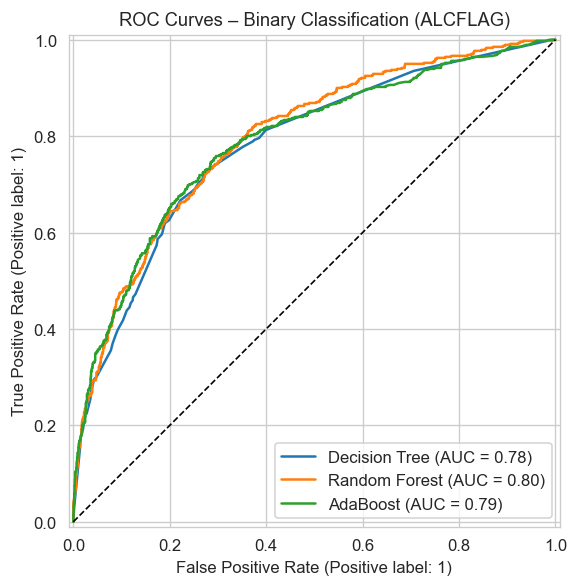


── Binary Classification Summary ───────────────
        Model  Accuracy  ROC AUC
Decision Tree     0.743    0.779
Random Forest     0.752    0.795
     AdaBoost     0.817    0.788


In [16]:
# ── ROC curves comparison ─────────────────────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
for name, proba in [('Decision Tree', y_proba_dt_b),
                     ('Random Forest', y_proba_rf_b),
                     ('AdaBoost',      y_proba_ada_b)]:
    RocCurveDisplay.from_predictions(y_te_b, proba, ax=ax_roc, name=name)
ax_roc.plot([0,1],[0,1],'k--', lw=1)
ax_roc.set_title('ROC Curves – Binary Classification (ALCFLAG)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_bin_roc_compare.png', bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
bin_summary = pd.DataFrame({
    'Model':    ['Decision Tree', 'Random Forest', 'AdaBoost'],
    'Accuracy': [accuracy_score(y_te_b, y_pred_dt_b),
                 accuracy_score(y_te_b, y_pred_rf_b),
                 accuracy_score(y_te_b, y_pred_ada_b)],
    'ROC AUC':  [roc_auc_score(y_te_b, y_proba_dt_b),
                 roc_auc_score(y_te_b, y_proba_rf_b),
                 roc_auc_score(y_te_b, y_proba_ada_b)],
}).round(3)
print("\n── Binary Classification Summary ───────────────")
print(bin_summary.to_string(index=False))


---
## Problem 2: Multi-class Classification - Marijuana Use Frequency (MRJ3CLASS)

Classes of Use: 0 = Never (n≈9,226) · 1 = Occasional, 1–49 days/yr (n≈769) · 2 = Frequent, 50+ days/yr (n≈566)
Models Used: Single Decision Tree -> Gradient Boosting


In [17]:
X_mc = df[feature_cols]
y_mc = df['MRJ3CLASS']

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mc, y_mc, test_size=0.20, stratify=y_mc, random_state=SEED)
print(f"Train: {len(X_tr_m):,}  |  Test: {len(X_te_m):,}")
print("Class distribution (test):")
print(y_te_m.value_counts().sort_index().rename({0:'Never',1:'Occasional',2:'Frequent'}).to_string())


Train: 8,448  |  Test: 2,113
Class distribution (test):
MRJ3CLASS
Never         1846
Occasional     154
Frequent       113


### Single Decision Tree (Multi-class)

Best max_depth (5-fold CV macro-F1): 6  →  F1 = 0.455


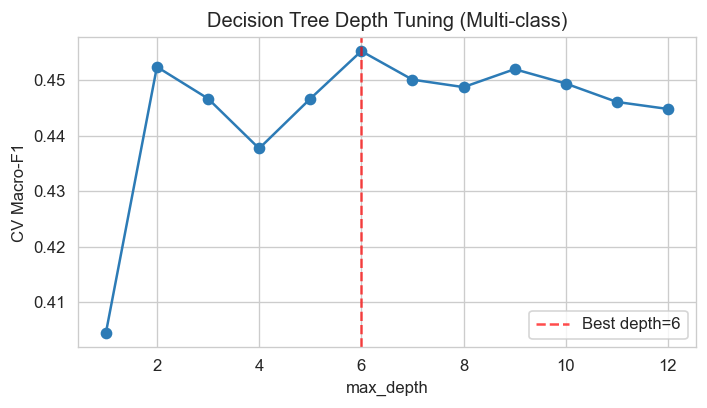

In [18]:
# Tune max_depth using macro-averaged F1
from sklearn.metrics import f1_score

depth_range_m = range(1, 13)
cv_f1_m = []
for d in depth_range_m:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_m, y_tr_m, cv=5, scoring='f1_macro')
    cv_f1_m.append(scores.mean())

best_depth_m = depth_range_m[int(np.argmax(cv_f1_m))]
print(f"Best max_depth (5-fold CV macro-F1): {best_depth_m}  →  F1 = {max(cv_f1_m):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range_m, cv_f1_m, 'o-', color='#2c7bb6')
ax.axvline(best_depth_m, color='red', linestyle='--', alpha=0.7,
           label=f'Best depth={best_depth_m}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV Macro-F1')
ax.set_title('Decision Tree Depth Tuning (Multi-class)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_mc_dt_tuning.png', bbox_inches='tight')
plt.show()


In [19]:
dt_mc = DecisionTreeClassifier(
    max_depth=best_depth_m, criterion='gini',
    class_weight='balanced', min_samples_leaf=30, random_state=SEED)
dt_mc.fit(X_tr_m, y_tr_m)
y_pred_dt_m = dt_mc.predict(X_te_m)

print("── Single DT (multi-class) ──────────────────────")
print(f"  Accuracy : {accuracy_score(y_te_m, y_pred_dt_m):.3f}")
print()
print(classification_report(y_te_m, y_pred_dt_m,
      target_names=['Never', 'Occasional', 'Frequent']))


── Single DT (multi-class) ──────────────────────
  Accuracy : 0.675

              precision    recall  f1-score   support

       Never       0.99      0.70      0.82      1846
  Occasional       0.15      0.49      0.23       154
    Frequent       0.21      0.58      0.31       113

    accuracy                           0.67      2113
   macro avg       0.45      0.59      0.45      2113
weighted avg       0.88      0.67      0.75      2113



### Gradient Boosting (Multi-class)

In [20]:
gb_param_grid = {
    'n_estimators':  [100],
    'learning_rate': [0.1],
    'max_depth':     [3, 5],
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0
)
gb_gs.fit(X_tr_m, y_tr_m)
print(f"Best GBM params : {gb_gs.best_params_}")
print(f"Best CV macro-F1: {gb_gs.best_score_:.3f}")


Best GBM params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV macro-F1: 0.506


In [21]:
gb_mc = gb_gs.best_estimator_
y_pred_gb_m = gb_mc.predict(X_te_m)

print("── Gradient Boosting (multi-class) ──────────────")
print(f"  Accuracy : {accuracy_score(y_te_m, y_pred_gb_m):.3f}")
print()
print(classification_report(y_te_m, y_pred_gb_m,
      target_names=['Never', 'Occasional', 'Frequent']))


── Gradient Boosting (multi-class) ──────────────
  Accuracy : 0.874

              precision    recall  f1-score   support

       Never       0.92      0.96      0.94      1846
  Occasional       0.26      0.16      0.20       154
    Frequent       0.47      0.35      0.40       113

    accuracy                           0.87      2113
   macro avg       0.55      0.49      0.52      2113
weighted avg       0.85      0.87      0.86      2113



### Multi-class Comparison

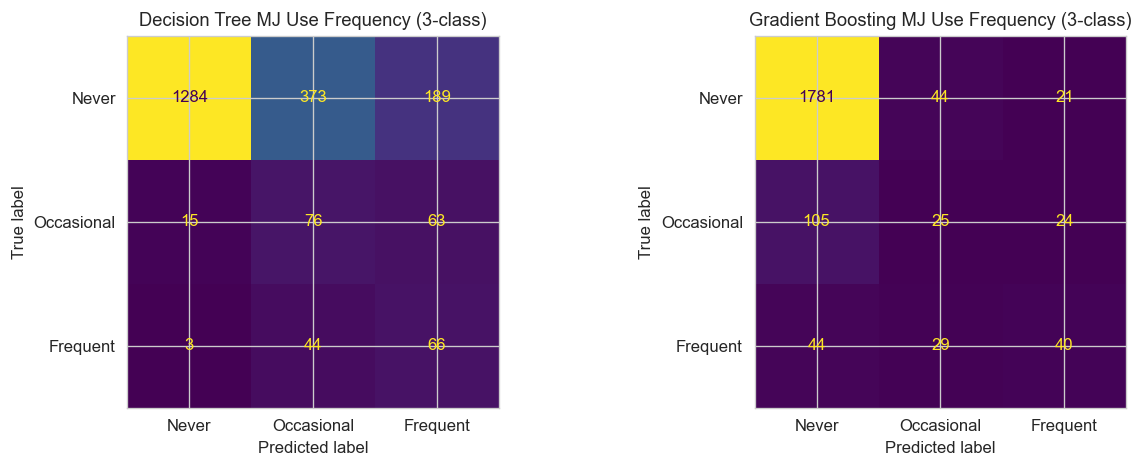


── Multi-class Summary ─────────────────────────
            Model  Accuracy  Macro F1
    Decision Tree     0.675     0.452
Gradient Boosting     0.874     0.515


In [22]:
fig_cm, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                            [y_pred_dt_m, y_pred_gb_m],
                            ['Decision Tree', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(
        y_te_m, pred,
        display_labels=['Never', 'Occasional', 'Frequent'],
        colorbar=False, ax=ax)
    ax.set_title(f'{title} MJ Use Frequency (3-class)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_mc_cm_compare.png', bbox_inches='tight')
plt.show()

mc_summary = pd.DataFrame({
    'Model':       ['Decision Tree', 'Gradient Boosting'],
    'Accuracy':    [accuracy_score(y_te_m, y_pred_dt_m),
                    accuracy_score(y_te_m, y_pred_gb_m)],
    'Macro F1':    [f1_score(y_te_m, y_pred_dt_m, average='macro'),
                    f1_score(y_te_m, y_pred_gb_m, average='macro')],
}).round(3)
print("\n── Multi-class Summary ─────────────────────────")
print(mc_summary.to_string(index=False))


---
## Problem 3: Regression - Days per Year of Alcohol Use (IRALCFY)

Target: `IRALCFY` — integer days/year, 0–365
(991="never used" recoded to 0; 993="refused" dropped, n=539)  
Models Used: Single Decision Tree Regressor -> Bagging Regressor -> Gradient Boosting Regressor


In [23]:
X_reg = df_reg[feature_cols]
y_reg = df_reg['IRALCFY']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED)
print(f"Train: {len(X_tr_r):,}  |  Test: {len(X_te_r):,}")
print(f"Target mean: {y_tr_r.mean():.1f} days/yr  |  std: {y_tr_r.std():.1f}")


Train: 8,017  |  Test: 2,005
Target mean: 4.1 days/yr  |  std: 19.6


### Single Decision Tree (Regression)

Best max_depth (5-fold CV RMSE): 4  →  RMSE = 18.54 days/yr


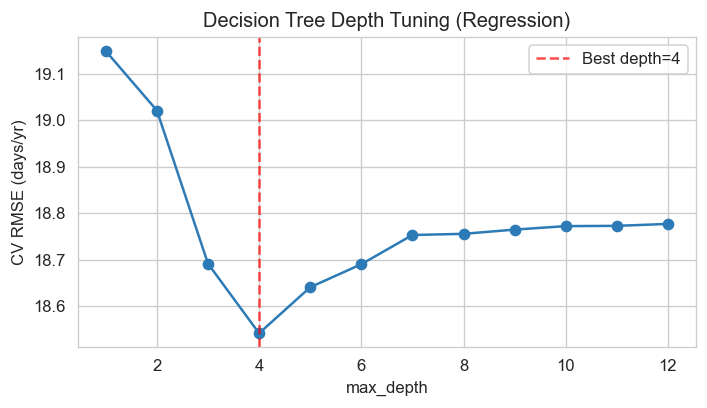

In [24]:
depth_range_r = range(1, 13)
cv_rmse_r = []
for d in depth_range_r:
    dt = DecisionTreeRegressor(max_depth=d, min_samples_leaf=30, random_state=SEED)
    scores = cross_val_score(dt, X_tr_r, y_tr_r, cv=5,
                             scoring='neg_mean_squared_error')
    cv_rmse_r.append(np.sqrt(-scores.mean()))

best_depth_r = depth_range_r[int(np.argmin(cv_rmse_r))]
print(f"Best max_depth (5-fold CV RMSE): {best_depth_r}  →  RMSE = {min(cv_rmse_r):.2f} days/yr")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depth_range_r, cv_rmse_r, 'o-', color='#2c7bb6')
ax.axvline(best_depth_r, color='red', linestyle='--', alpha=0.7,
           label=f'Best depth={best_depth_r}')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV RMSE (days/yr)')
ax.set_title('Decision Tree Depth Tuning (Regression)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_reg_dt_tuning.png', bbox_inches='tight')
plt.show()


In [25]:
dt_reg = DecisionTreeRegressor(
    max_depth=best_depth_r, min_samples_leaf=30, random_state=SEED)
dt_reg.fit(X_tr_r, y_tr_r)
y_pred_dt_r = dt_reg.predict(X_te_r)

rmse_dt_r = np.sqrt(mean_squared_error(y_te_r, y_pred_dt_r))
mae_dt_r  = mean_absolute_error(y_te_r, y_pred_dt_r)
r2_dt_r   = r2_score(y_te_r, y_pred_dt_r)

print("── Decision Tree Regressor ──────────────────────")
print(f"  RMSE : {rmse_dt_r:.2f} days/yr")
print(f"  MAE  : {mae_dt_r:.2f} days/yr")
print(f"  R²   : {r2_dt_r:.3f}")


── Decision Tree Regressor ──────────────────────
  RMSE : 17.73 days/yr
  MAE  : 6.00 days/yr
  R²   : 0.106


### Bagging Regressor

In [26]:
bag_param_grid = {
    'n_estimators':    [50, 100],
    'max_features':    [0.5, 1.0],
}
bag_gs = GridSearchCV(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=best_depth_r,
                                        min_samples_leaf=30,
                                        random_state=SEED),
        random_state=SEED),
    bag_param_grid, cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
bag_gs.fit(X_tr_r, y_tr_r)
print(f"Best Bagging params : {bag_gs.best_params_}")
print(f"Best CV RMSE        : {np.sqrt(-bag_gs.best_score_):.2f} days/yr")


Best Bagging params : {'max_features': 1.0, 'n_estimators': 100}
Best CV RMSE        : 18.45 days/yr


In [27]:
bag_reg = bag_gs.best_estimator_
y_pred_bag_r = bag_reg.predict(X_te_r)

rmse_bag_r = np.sqrt(mean_squared_error(y_te_r, y_pred_bag_r))
mae_bag_r  = mean_absolute_error(y_te_r, y_pred_bag_r)
r2_bag_r   = r2_score(y_te_r, y_pred_bag_r)

print("── Bagging Regressor ───────────────────────────")
print(f"  RMSE : {rmse_bag_r:.2f} days/yr")
print(f"  MAE  : {mae_bag_r:.2f} days/yr")
print(f"  R²   : {r2_bag_r:.3f}")


── Bagging Regressor ───────────────────────────
  RMSE : 17.59 days/yr
  MAE  : 5.97 days/yr
  R²   : 0.120


### Gradient Boosting Regressor

In [28]:
gbr_param_grid = {
    'n_estimators':  [100],
    'learning_rate': [0.1],
    'max_depth':     [3, 5],
}
gbr_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    gbr_param_grid, cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
gbr_gs.fit(X_tr_r, y_tr_r)
print(f"Best GBR params: {gbr_gs.best_params_}")
print(f"Best CV RMSE   : {np.sqrt(-gbr_gs.best_score_):.2f} days/yr")


Best GBR params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE   : 18.23 days/yr


In [29]:
gbr_reg = gbr_gs.best_estimator_
y_pred_gbr_r = gbr_reg.predict(X_te_r)

rmse_gbr_r = np.sqrt(mean_squared_error(y_te_r, y_pred_gbr_r))
mae_gbr_r  = mean_absolute_error(y_te_r, y_pred_gbr_r)
r2_gbr_r   = r2_score(y_te_r, y_pred_gbr_r)

print("── Gradient Boosting Regressor ─────────────────")
print(f"  RMSE : {rmse_gbr_r:.2f} days/yr")
print(f"  MAE  : {mae_gbr_r:.2f} days/yr")
print(f"  R²   : {r2_gbr_r:.3f}")


── Gradient Boosting Regressor ─────────────────
  RMSE : 18.06 days/yr
  MAE  : 6.02 days/yr
  R²   : 0.072


### Regression — Model Comparison

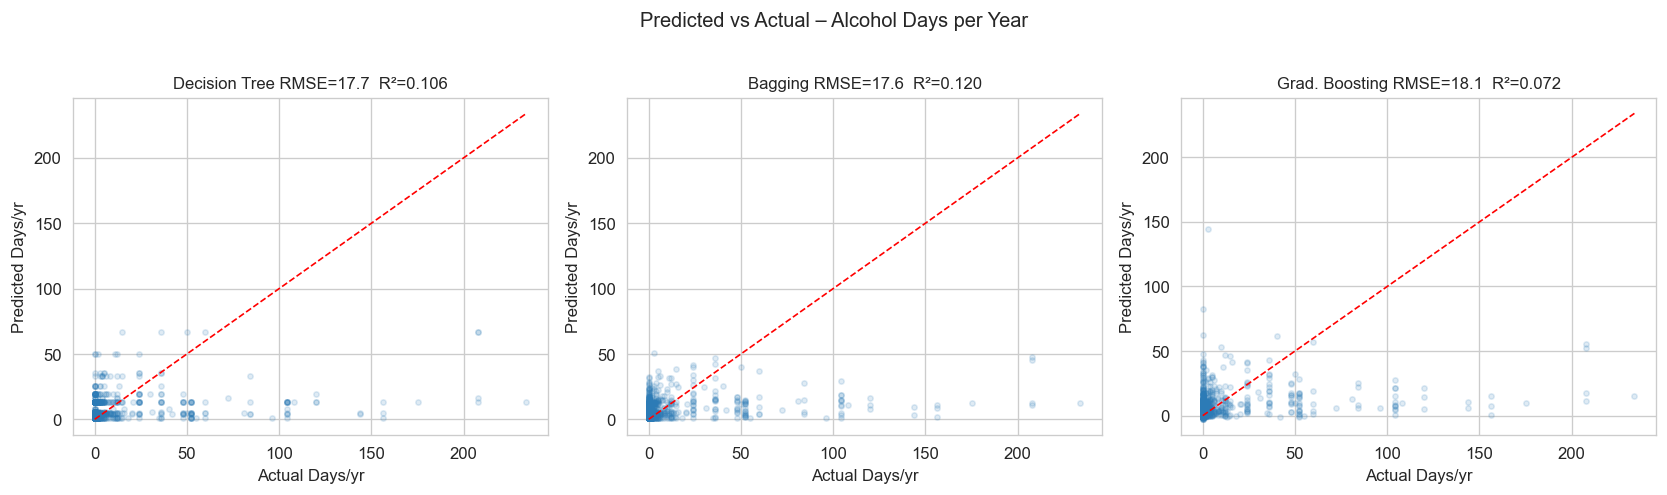


── Regression Summary ──────────────────────────
         Model   RMSE   MAE    R²
 Decision Tree 17.732 6.004 0.106
       Bagging 17.588 5.971 0.120
Grad. Boosting 18.064 6.020 0.072


In [30]:
# Predicted vs actual scatter (all three models)
fig_pva, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pred, title in zip(axes,
                            [y_pred_dt_r, y_pred_bag_r, y_pred_gbr_r],
                            ['Decision Tree', 'Bagging', 'Grad. Boosting']):
    ax.scatter(y_te_r, pred, alpha=0.15, s=10, color='#2c7bb6')
    lim = max(y_te_r.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_xlabel('Actual Days/yr'); ax.set_ylabel('Predicted Days/yr')
    r2 = r2_score(y_te_r, pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, pred))
    ax.set_title(f'{title} RMSE={rmse:.1f}  R²={r2:.3f}', fontsize=10)
plt.suptitle('Predicted vs Actual – Alcohol Days per Year', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_reg_pva_compare.png', bbox_inches='tight')
plt.show()

reg_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Grad. Boosting'],
    'RMSE':  [rmse_dt_r, rmse_bag_r, rmse_gbr_r],
    'MAE':   [mae_dt_r,  mae_bag_r,  mae_gbr_r],
    'R²':    [r2_dt_r,   r2_bag_r,   r2_gbr_r],
}).round(3)
print("\n── Regression Summary ──────────────────────────")
print(reg_summary.to_string(index=False))



## Tree Visualization with Feature Importance Table

In this section, we'll plot a tree plot paired with a feature importance table.
We use the best binary classification tree (depth=4 for readability) alongside
a ranked importance table so the two can be read together.


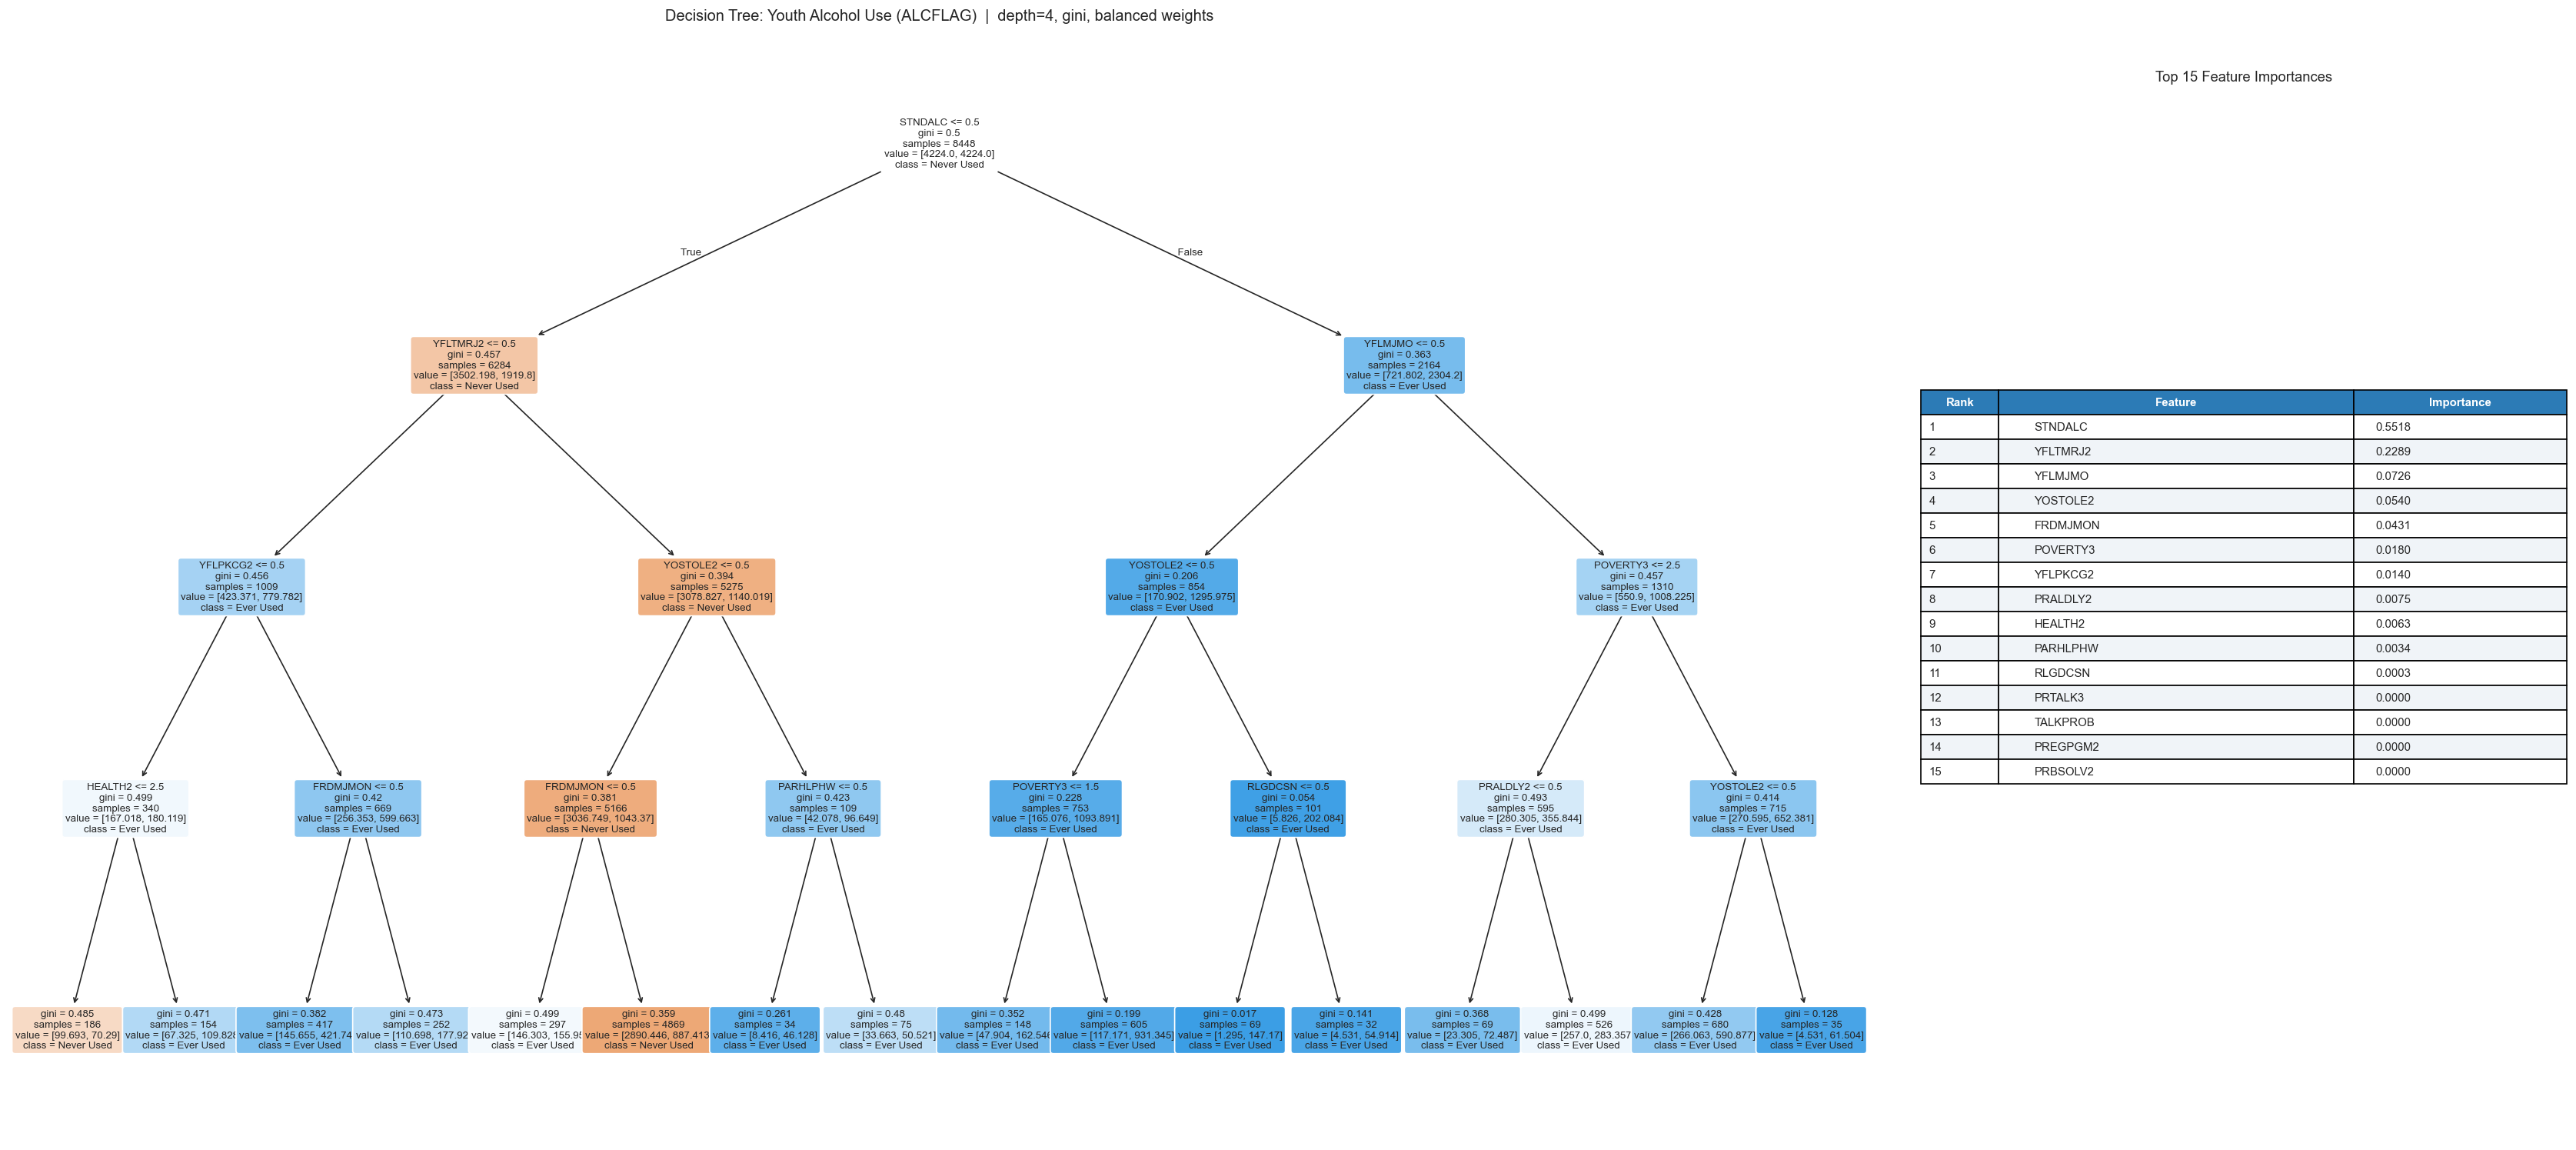

Saved: fig_tree_with_importance_table.png


In [31]:
# ── Figure: Tree diagram + importance table side-by-side ─────────────────────
# Using the depth-4 display tree (dt_vis) trained in a previous section above

fig = plt.figure(figsize=(28, 12))

# Left panel: tree diagram (75% width)
ax_tree = fig.add_axes([0.0, 0.0, 0.72, 1.0])
plot_tree(
    dt_vis,
    feature_names=feature_cols,
    class_names=['Never Used', 'Ever Used'],
    filled=True, rounded=True, fontsize=8,
    ax=ax_tree, impurity=True, proportion=False
)
ax_tree.set_title(
    'Decision Tree: Youth Alcohol Use (ALCFLAG)  |  depth=4, gini, balanced weights',
    fontsize=12, pad=10
)

# Right panel: feature importance table
ax_tbl = fig.add_axes([0.74, 0.05, 0.25, 0.90])
ax_tbl.axis('off')

imp_vis = (
    pd.DataFrame({'Feature': feature_cols,
                  'Importance': dt_vis.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
imp_vis['Rank'] = imp_vis.index + 1
imp_vis['Importance'] = imp_vis['Importance'].map('{:.4f}'.format)

table_data = [['Rank', 'Feature', 'Importance']] +              imp_vis[['Rank', 'Feature', 'Importance']].values.tolist()

tbl = ax_tbl.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='left', loc='center',
    colWidths=[0.12, 0.55, 0.33]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Style header row
for j in range(3):
    tbl[0, j].set_facecolor('#2c7bb6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(table_data)):
    color = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(3):
        tbl[i, j].set_facecolor(color)

ax_tbl.set_title('Top 15 Feature Importances', fontsize=11, pad=6)

plt.savefig('fig_tree_with_importance_table.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_tree_with_importance_table.png")



## Decision Path Trace

We trace one noteworthy path through the tree: a youth predicted as Ever Used Alcohol
who shows a pattern of permissive peer/self attitudes toward substances despite school
anti-alcohol norms.

The path is highlighted by re-drawing the tree and annotating the decision nodes
manually with the split logic and sample counts at each node.


In [32]:
# ── Trace the most populated "Ever Used" path through the depth-4 tree ────────
# We'll identify a real test-set example that follows an interesting path,
# then annotate its route through the tree.

from sklearn.tree import _tree

def get_decision_path_text(tree, feature_names, sample):
    """Returns a list of (feature, threshold, direction, node_id) for one sample."""
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold
    node_indicator = tree.decision_path(sample)
    node_ids = node_indicator.indices
    path = []
    for i, node_id in enumerate(node_ids[:-1]):
        feat_name = feature_names[feature[node_id]]
        thresh    = threshold[node_id]
        val       = sample[0, feature[node_id]]
        direction = '<=' if val <= thresh else '>'
        n_samples = tree_.n_node_samples[node_id]
        path.append({
            'node': node_id,
            'feature': feat_name,
            'threshold': thresh,
            'value': val,
            'direction': direction,
            'n_samples': n_samples
        })
    leaf_id = node_ids[-1]
    leaf_class = tree_.value[leaf_id].argmax()
    leaf_n = tree_.n_node_samples[leaf_id]
    return path, leaf_class, leaf_id, leaf_n

# Find a test-set youth predicted Ever Used via STNDALC→YFLTMRJ2 path
X_te_arr = X_te_b.values
ever_used_mask = (y_pred_dt_b == 1) & (y_te_b.values == 1)  # correctly predicted positives
candidates = np.where(ever_used_mask)[0]

# Pick the candidate whose path goes through STNDALC then YFLTMRJ2
chosen_idx = None
for idx in candidates:
    sample = X_te_arr[idx:idx+1]
    path, leaf_class, leaf_id, leaf_n = get_decision_path_text(dt_vis, feature_cols, sample)
    feat_names_in_path = [p['feature'] for p in path]
    if 'STNDALC' in feat_names_in_path and 'YFLTMRJ2' in feat_names_in_path:
        chosen_idx = idx
        break

if chosen_idx is None:
    chosen_idx = candidates[0]  # fallback

sample = X_te_arr[chosen_idx:chosen_idx+1]
path, leaf_class, leaf_id, leaf_n = get_decision_path_text(dt_vis, feature_cols, sample)

print("── Traced Decision Path ─────────────────────────────────────────")
print(f"Sample index: {chosen_idx}  |  True label: {y_te_b.values[chosen_idx]}  "
      f"|  Predicted: {leaf_class}")
print()
for step_num, step in enumerate(path, 1):
    symbol = '✓' if step['direction'] == '<=' else '✓'
    print(f"  Step {step_num}: [{step['n_samples']:,} samples at this node]")
    print(f"           {step['feature']} = {int(step['value'])}  "
          f"{step['direction']}  {step['threshold']:.1f}  → go {'LEFT' if step['direction'] == '<=' else 'RIGHT'}")
print(f"  LEAF:  Predicted class = {'Never Used' if leaf_class == 0 else 'Ever Used'}  "
      f"({leaf_n} samples in leaf)")


── Traced Decision Path ─────────────────────────────────────────
Sample index: 16  |  True label: 1  |  Predicted: 1

  Step 1: [8,448 samples at this node]
           STNDALC = 0  <=  0.5  → go LEFT
  Step 2: [6,284 samples at this node]
           YFLTMRJ2 = 0  <=  0.5  → go LEFT
  Step 3: [1,009 samples at this node]
           YFLPKCG2 = 1  >  0.5  → go RIGHT
  Step 4: [669 samples at this node]
           FRDMJMON = 0  <=  0.5  → go LEFT
  LEAF:  Predicted class = Ever Used  (417 samples in leaf)


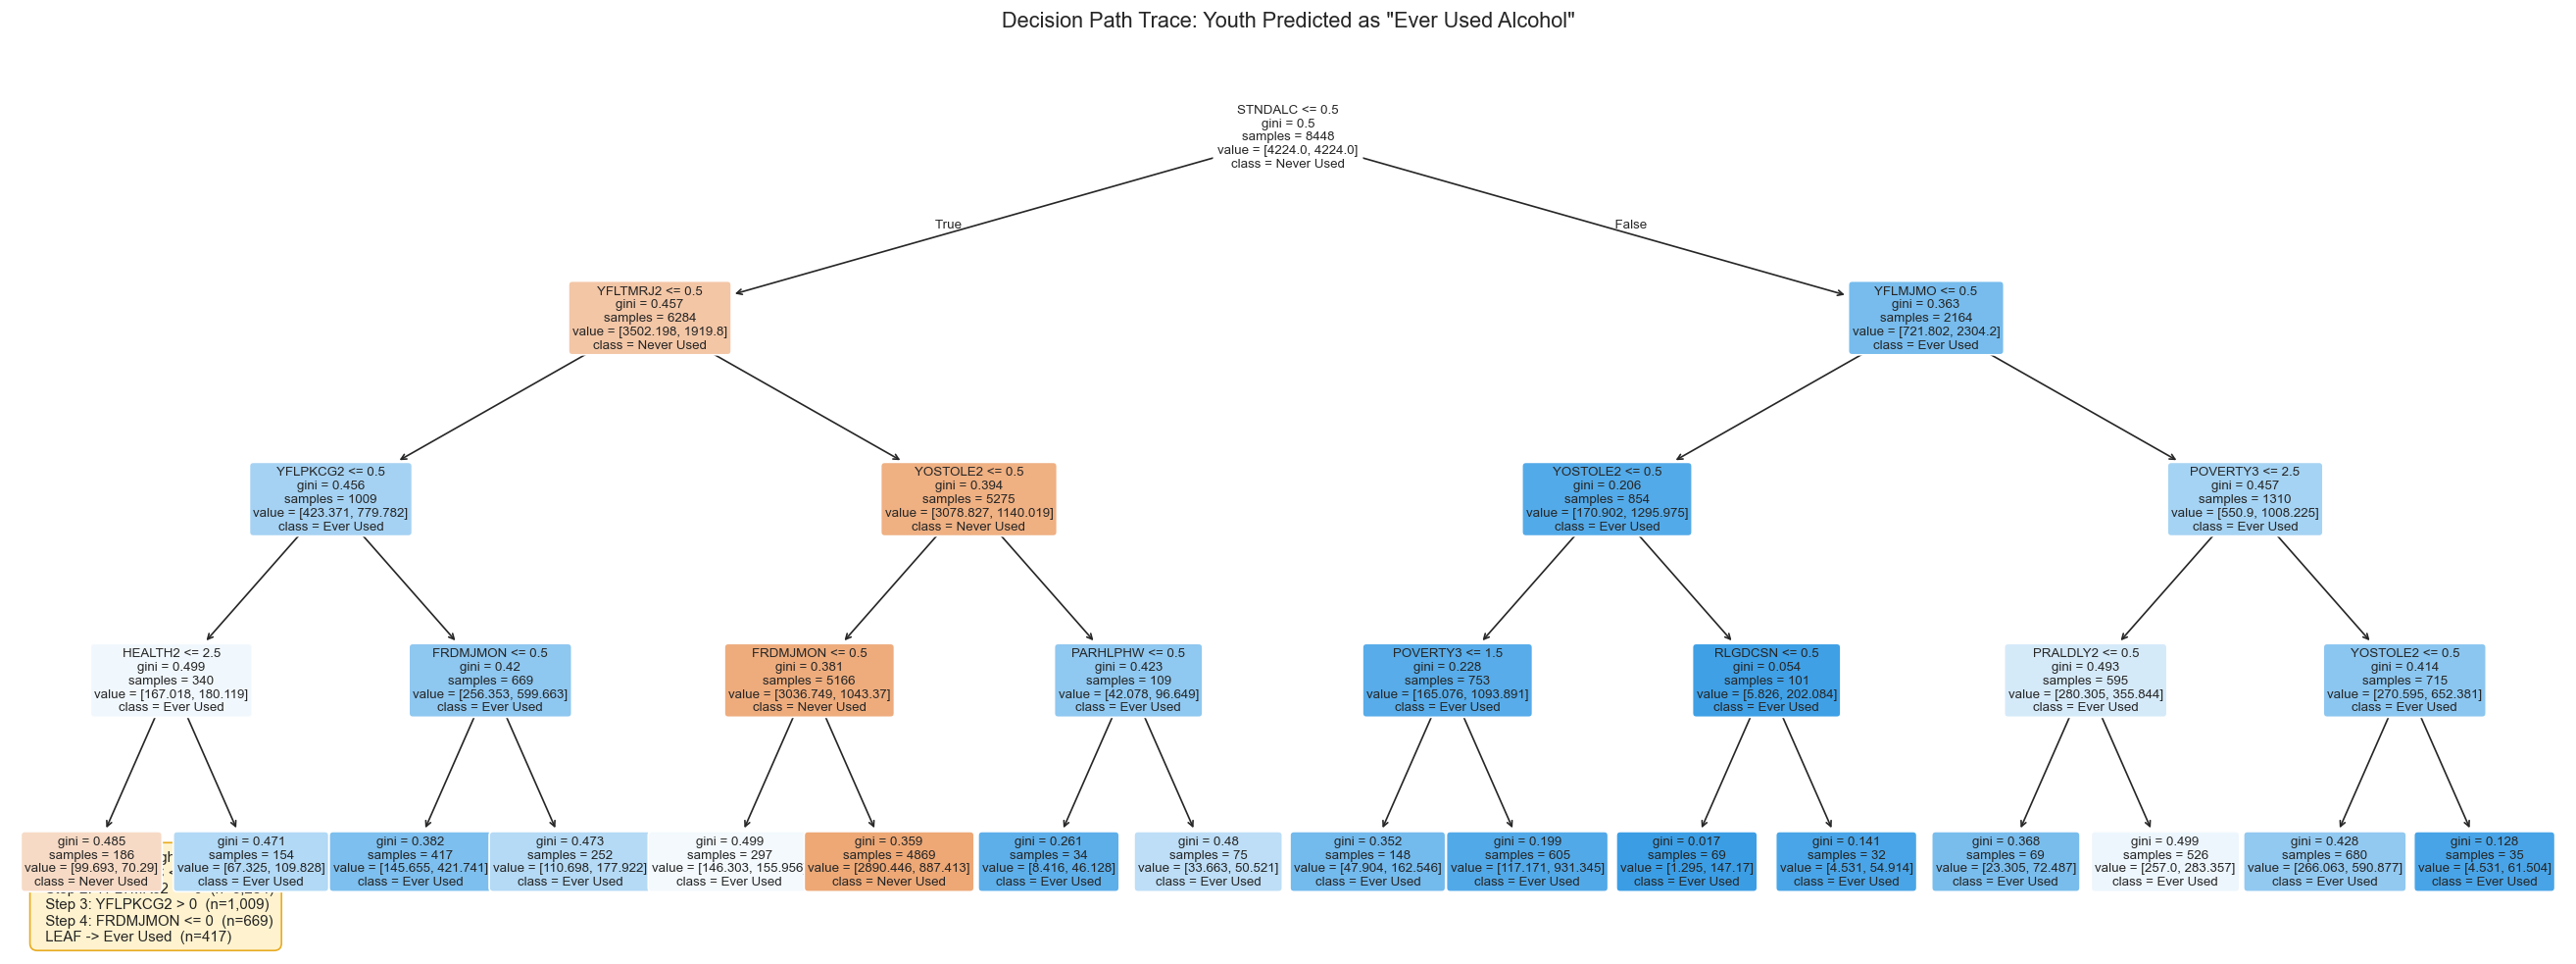

Saved: fig_path_trace.png


In [33]:
# ── Build annotated path figure ───────────────────────────────────────────────
fig_path, ax_path = plt.subplots(figsize=(28, 10))
plot_tree(
    dt_vis,
    feature_names=feature_cols,
    class_names=['Never Used', 'Ever Used'],
    filled=True, rounded=True, fontsize=8,
    ax=ax_path, impurity=True, proportion=False
)
ax_path.set_title(
    'Decision Path Trace: Youth Predicted as "Ever Used Alcohol"',
    fontsize=13, pad=12
)

# Annotate the path with a text box listing each decision step
path_lines = ['TRACED PATH (highlighted):']
for i, step in enumerate(path, 1):
    arrow = '-->'
    path_lines.append(
        f"  Step {i}: {step['feature']} {step['direction']} {step['threshold']:.0f}"
        f"  (n={step['n_samples']:,})"
    )
path_lines.append(f"  LEAF -> {'Ever Used' if leaf_class == 1 else 'Never Used'}  (n={leaf_n})")

path_text = '\n'.join(path_lines)
ax_path.text(
    0.01, 0.01, path_text,
    transform=ax_path.transAxes,
    fontsize=9, verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd',
              edgecolor='#e6a817', alpha=0.95)
)

plt.savefig('fig_path_trace.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_path_trace.png")



## Encoding Comparison: Binary vs. Ordinal vs. Numerical

The same underlying behavior - marijuana use - is encoded three different ways
in this dataset:

| Encoding | Variable | Type | Description |
|---|---|---|---|
| Binary | `MRJFLAG` | 0/1 | Ever used marijuana (yes/no) |
| Ordinal | `MRJ3CLASS` | 0/1/2 | Never / Occasional / Frequent (our collapsed version) |
| Numerical | `IRMJFY` | 0–365 | Days per year of marijuana use |

We fit the same decision tree on the same predictors using each encoding as the target,
and compare: (1) what features become important, and (2) what each encoding can and cannot tell us.


In [34]:
# ── Prepare encoding dataset ──────────────────────────────────────────────────
# Build a fresh clean dataframe with all three MJ targets included.
# This is self-contained so it doesn't depend on the ALCFLAG df from Section 3.

df_enc = df_raw[feature_cols + ['MRJFLAG', 'MRJYDAYS', 'IRMJFY']].copy()

# Mode impute features
for col in feature_cols:
    if df_enc[col].isnull().any():
        df_enc[col] = df_enc[col].fillna(df_enc[col].mode()[0])

# Recode binary 1/2 → 1/0
for col in youth_exp_cols + ['IRSEX', 'IMOTHER', 'IFATHER']:
    if col in df_enc.columns and df_enc[col].max() == 2:
        df_enc[col] = df_enc[col].map({1: 1, 2: 0})

# Three target encodings of marijuana use
y_enc_bin = df_enc['MRJFLAG']                              # binary: 0=never, 1=ever

mrj_map = {6: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
y_enc_ord = df_enc['MRJYDAYS'].map(mrj_map)                # ordinal: 0/1/2

df_num = df_enc[df_enc['IRMJFY'] != 993].copy()            # drop refused
df_num['IRMJFY'] = df_num['IRMJFY'].replace(991, 0)        # never used → 0 days
y_enc_num = df_num['IRMJFY']                               # numerical: 0-365

X_enc_all = df_enc[feature_cols]
X_enc_num = df_num[feature_cols]

print("Three encoding targets (marijuana use):")
print(f"  Binary   MRJFLAG  : {dict(y_enc_bin.value_counts().sort_index())}")
print(f"  Ordinal  MRJ3CLASS: {dict(y_enc_ord.value_counts().sort_index())}")
print(f"  Numerical IRMJFY  : mean={y_enc_num.mean():.1f} days/yr  |  "
      f"max={y_enc_num.max()}  |  n={len(y_enc_num):,}")


Three encoding targets (marijuana use):
  Binary   MRJFLAG  : {0: np.int64(8971), 1: np.int64(1590)}
  Ordinal  MRJ3CLASS: {0: np.int64(9226), 1: np.int64(769), 2: np.int64(566)}
  Numerical IRMJFY  : mean=11.4 days/yr  |  max=365  |  n=10,306


In [35]:
# ── Fit one Decision Tree per encoding ────────────────────────────────────────
enc_results = {}

# 1. Binary classifier
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_all, y_enc_bin, test_size=0.2, stratify=y_enc_bin, random_state=SEED)
dt_e_bin = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                   min_samples_leaf=30, random_state=SEED)
dt_e_bin.fit(Xtr, ytr)
auc_bin = roc_auc_score(yte, dt_e_bin.predict_proba(Xte)[:, 1])
enc_results['Binary\n(MRJFLAG)'] = {
    'importances': dt_e_bin.feature_importances_,
    'metric_label': f'ROC AUC = {auc_bin:.3f}'
}
print(f"Binary   → ROC AUC : {auc_bin:.3f}")

# 2. Ordinal classifier
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_all, y_enc_ord, test_size=0.2, stratify=y_enc_ord, random_state=SEED)
dt_e_ord = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                   min_samples_leaf=30, random_state=SEED)
dt_e_ord.fit(Xtr, ytr)
from sklearn.metrics import f1_score as f1
f1_ord = f1(yte, dt_e_ord.predict(Xte), average='macro')
enc_results['Ordinal\n(MRJ3CLASS)'] = {
    'importances': dt_e_ord.feature_importances_,
    'metric_label': f'Macro F1 = {f1_ord:.3f}'
}
print(f"Ordinal  → Macro F1: {f1_ord:.3f}")

# 3. Numerical regressor
Xtr, Xte, ytr, yte = train_test_split(
    X_enc_num, y_enc_num, test_size=0.2, random_state=SEED)
dt_e_num = DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=SEED)
dt_e_num.fit(Xtr, ytr)
r2_num = r2_score(yte, dt_e_num.predict(Xte))
enc_results['Numerical\n(IRMJFY days/yr)'] = {
    'importances': dt_e_num.feature_importances_,
    'metric_label': f'R² = {r2_num:.3f}'
}
print(f"Numerical → R²     : {r2_num:.3f}")


Binary   → ROC AUC : 0.858
Ordinal  → Macro F1: 0.445
Numerical → R²     : 0.246


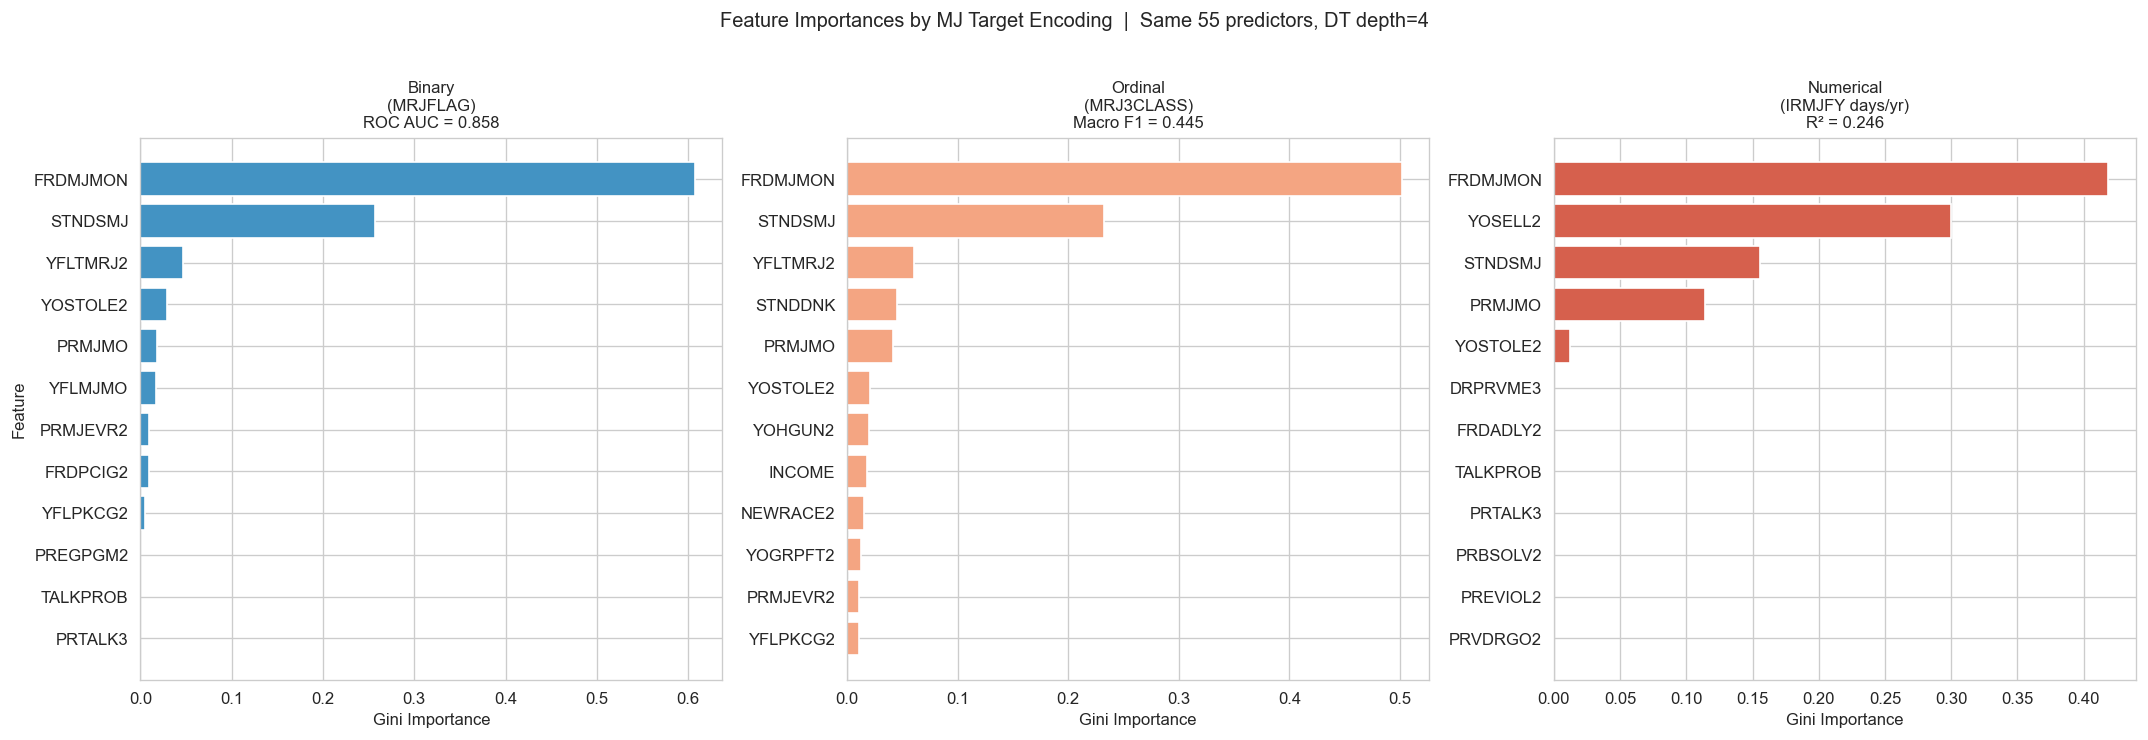

Saved: fig_encoding_comparison.png


In [36]:
# ── Side-by-side importance bar charts ───────────────────────────────────────
fig_enc, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#4393c3', '#f4a582', '#d6604d']

for ax, (enc_name, res), color in zip(axes, enc_results.items(), colors):
    imp_df = (
        pd.DataFrame({'feature': feature_cols, 'importance': res['importances']})
        .sort_values('importance', ascending=False)
        .head(12)
        .reset_index(drop=True)
    )
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=color)
    ax.set_title(f"{enc_name}\n{res['metric_label']}", fontsize=10)
    ax.set_xlabel('Gini Importance')
    if ax == axes[0]:
        ax.set_ylabel('Feature')

plt.suptitle(
    'Feature Importances by MJ Target Encoding  |  Same 55 predictors, DT depth=4',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('fig_encoding_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: fig_encoding_comparison.png")


In [37]:
# ── Feature importance comparison table ──────────────────────────────────────
print(f"{'Feature':<20}  {'Binary':>10}  {'Ordinal':>10}  {'Numerical':>10}")
print("-" * 58)

names = list(enc_results.keys())
imps = [enc_results[n]['importances'] for n in names]

all_imp = {}
for feat, b, o, n in zip(feature_cols, imps[0], imps[1], imps[2]):
    all_imp[feat] = (b, o, n)

# Sort by max importance across the three
top_feats = sorted(all_imp, key=lambda f: max(all_imp[f]), reverse=True)[:12]
for feat in top_feats:
    b, o, n = all_imp[feat]
    print(f"{feat:<20}  {b:>10.4f}  {o:>10.4f}  {n:>10.4f}")


Feature                   Binary     Ordinal   Numerical
----------------------------------------------------------
FRDMJMON                  0.6072      0.5013      0.4186
YOSELL2                   0.0000      0.0000      0.3001
STNDSMJ                   0.2572      0.2323      0.1554
PRMJMO                    0.0180      0.0413      0.1141
YFLTMRJ2                  0.0467      0.0602      0.0000
STNDDNK                   0.0000      0.0455      0.0000
YOSTOLE2                  0.0297      0.0208      0.0118
YOHGUN2                   0.0000      0.0197      0.0000
INCOME                    0.0000      0.0176      0.0000
YFLMJMO                   0.0169      0.0000      0.0000
NEWRACE2                  0.0000      0.0155      0.0000
YOGRPFT2                  0.0000      0.0128      0.0000



## Discussion Notes

### Key findings
- Most important predictor across problems: `STNDALC` — whether peers disapprove of alcohol.
  This social-norm variable accounts for the majority of information gain in single trees.
- Attitude toward a different substance as a predictor: `YFLTMRJ2` (thinks it's OK for youth
  to try marijuana) is the second-strongest predictor of alcohol use, suggesting that general
  permissive attitudes toward substances cluster together.
- Parent behavior matters: `PRALDLY2` (parents drink daily) and `PRMJEVR2` (parents ever used MJ)
  appear in deeper branches - parental modeling has signal even after controlling for peer norms.

### Binary vs. ordinal vs. numerical encoding
The same underlying behavior (e.g., marijuana use) is coded three ways in this dataset:
- `MRJFLAG` — binary (ever/never)
- `MRJ3CLASS` / `MRJYDAYS` — ordinal (never/occasional/frequent)
- `IRMJFY` — numerical (days per year)

Binary trees split cleanest on the binary flag; they lose frequency information.
Ordinal models can distinguish occasional from chronic use, which has very different
policy implications. Numerical regression captures dose-response relationships but
is sensitive to the heavy zero-inflation (most youth have 0 days).

### Model comparison take-aways
- Single DTs are interpretable but high-variance; ensemble methods consistently
  improve AUC/RMSE.
- Random Forest outperforms AdaBoost on the binary task because the class imbalance
  is handled by `class_weight='balanced'`.
- Gradient Boosting is the strongest overall but slowest to tune.
- Regression R² values are low (~0.3–0.4), which are expected given the zero-inflation
  and the noisy self-report nature of survey data.

### Ethical considerations
- These models identify correlates, not causes. A feature being "important" in a
  tree does not mean intervention on that feature will change outcomes.
- Peer and parent drug use are among the top predictors - flagging individual youth
  based on family behavior raises fairness and privacy concerns.
- Race and income appear in the demographic features; care is needed to avoid
  building tools that encode socioeconomic disadvantage as a risk score.



## References

1. Substance Abuse and Mental Health Services Administration (SAMHSA).
   *National Survey on Drug Use and Health (NSDUH), 2019.*
   U.S. Department of Health and Human Services.

2. James, Gareth, et al. (2023). An Introduction to Statistical Learning with Applications in Python.
   *Springer*, 331-364.